In [14]:
import pandas as pd
import numpy as np

In [2]:
#=============================
#   Load CSV file
#=============================
df=pd.read_csv('mana-data-invoices.csv', sep=',', encoding='utf-8',header=0)

# Show column name
print("Columns in data set:\n")
print(df.columns.tolist(),"\n")
print(df.dtypes)
#check column names
df.head()

Columns in data set:

['invoice_id', 'customer_code', 'product_code', 'quantity', 'unit_price', 'invoice_date', 'row_id', 'total_buy', 'Gregorian_Date'] 

invoice_id          int64
customer_code      object
product_code        int64
quantity          float64
unit_price          int64
invoice_date       object
row_id              int64
total_buy           int64
Gregorian_Date     object
dtype: object


,invoice_id,customer_code,product_code,quantity,unit_price,invoice_date,row_id,total_buy,Gregorian_Date
0,3,customer1,879200,10.0,950000,10/01/1404,1,9500000,3/30/2025
1,3,customer1,879193,8.0,1400000,10/01/1404,2,11200000,3/30/2025
2,3,customer1,879516052,5.0,450000,10/01/1404,3,2250000,3/30/2025
3,5,customer3,115,4.0,70000,12/01/1404,1,280000,4/1/2025
4,5,customer3,855341113,1.0,617000,12/01/1404,2,617000,4/1/2025


In [9]:
#=========================================
#  Converting and Adding some Columns
#=========================================

#Rename two columns to a simpler name
df.rename(columns = {
       'Gregorian_Date': 'date',
       'total_buy':'revenue'
}, inplace = True)

df['product_code'] = df['product_code'].astype(str)

#Check if 'Gregorian_date' exists, otherwise convert 'date' to datetime
if 'Gregorian_Date' in df.columns:
    df['date'] = pd.to_datetime(df['Gregorian_Date'])
    df.drop(columns=['Gregorian_Date'],inplace=True)
    print("Converted Gregorian_Date to 'date")
    
elif 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    print("'date' column already exists!") 
    
#Add weekday column
df['weekday'] = df['date'].dt.day_name()

df['weekday_num'] = df['date'].dt.weekday

#Check Results
print("\n First 5 rows:")
print(df[['date','weekday','weekday_num']].head())

print("\n Weekday distribution:")
print(df['weekday'].value_counts(),"\n")

df.head()

'date' column already exists!

 First 5 rows:
        date  weekday  weekday_num
0 2025-03-30   Sunday            6
1 2025-03-30   Sunday            6
2 2025-03-30   Sunday            6
3 2025-04-01  Tuesday            1
4 2025-04-01  Tuesday            1

 Weekday distribution:
weekday
Tuesday      869
Thursday     689
Sunday       554
Wednesday    530
Monday       505
Saturday     485
Friday       457
Name: count, dtype: int64 



,invoice_id,customer_code,product_code,quantity,unit_price,invoice_date,row_id,revenue,date,weekday,weekday_num
0,3,customer1,879200,10.0,950000,10/01/1404,1,9500000,2025-03-30,Sunday,6
1,3,customer1,879193,8.0,1400000,10/01/1404,2,11200000,2025-03-30,Sunday,6
2,3,customer1,879516052,5.0,450000,10/01/1404,3,2250000,2025-03-30,Sunday,6
3,5,customer3,115,4.0,70000,12/01/1404,1,280000,2025-04-01,Tuesday,1
4,5,customer3,855341113,1.0,617000,12/01/1404,2,617000,2025-04-01,Tuesday,1


In [10]:
#===========================================
#    Calculating revenue per weekday
#===========================================
weekly_revenue = df.groupby('weekday')['revenue'].sum().reset_index()

#Calculate total revenue
total_revenue = df['revenue'].sum()

#Calculate percentage
weekly_revenue['percentage'] = (weekly_revenue['revenue']/total_revenue)*100

#Sort by percentage
weekly_revenue = weekly_revenue.sort_values('percentage',ascending= False)

print("\n Weekly Sales Distribution (% of total):")
print(weekly_revenue.to_string(index=False))


# Display as percentage
print("\n Weekly Sales Distribution (% of total):")
for index, row in weekly_revenue.iterrows():
    print(f"    {row['weekday']}: {row['percentage']:.2f}%")
    


 Weekly Sales Distribution (% of total):
  weekday     revenue  percentage
 Thursday 32328328325   19.631670
Wednesday 28153074585   17.096209
   Sunday 26291596975   15.965810
  Tuesday 25446212151   15.452443
 Saturday 19364913490   11.759519
   Monday 17324594135   10.520517
   Friday 15765648673    9.573833

 Weekly Sales Distribution (% of total):
    Thursday: 19.63%
    Wednesday: 17.10%
    Sunday: 15.97%
    Tuesday: 15.45%
    Saturday: 11.76%
    Monday: 10.52%
    Friday: 9.57%


In [11]:
#==============================================
# Calculating revenue percentages per customer
#==============================================

customer_revenue = df.groupby('customer_code')['revenue'].sum().reset_index()
customer_revenue['percentage'] = (customer_revenue['revenue']/total_revenue)*100
customer_revenue = customer_revenue.sort_values('percentage',ascending= False)

print("\n Customer Sales Distribution (% of total):")
for index, row in customer_revenue.head(10).iterrows():
    print(f" {row['customer_code']}: {row['percentage']:.2f}%")


 Customer Sales Distribution (% of total):
 customer31: 22.79%
 customer58: 11.79%
 customer13: 8.78%
 customer32: 5.16%
 customer81: 4.78%
 customer9: 4.52%
 customer8: 3.01%
 customer40: 2.34%
 customer7: 2.16%
 customer42: 2.12%


In [13]:
#================================================
# Calculating revenue percentages per product
#================================================

product_revenue = df.groupby('product_code')['revenue'].sum().reset_index()
product_revenue['percentage'] = (product_revenue['revenue']/total_revenue)*100
product_revenue = product_revenue.sort_values('percentage',ascending = False)


print("\n Product Sales Distribution (% of total):")
for index, row in product_revenue.head(10).iterrows():
    print(f" {row['product_code']}:  {row['percentage']:.2f}%")


 Product Sales Distribution (% of total):
 813121016:  11.98%
 813121020:  3.72%
 819141020:  3.06%
 813121025:  3.00%
 861641102:  2.89%
 855212402:  2.79%
 163642:  2.15%
 819141025:  2.02%
 1134:  1.94%
 819161020:  1.67%


In [15]:

# Calculate the revenue of each customer
customer_revenue = df.groupby('customer_code')['revenue'].sum().sort_values(ascending=False)

# Calculate the cumulative percentage
cumulative_revenue = customer_revenue.cumsum()
total_revenue = customer_revenue.sum()
cumulative_percent = (cumulative_revenue / total_revenue) * 100

# Number of customers and percentage of 20%
num_customers = len(customer_revenue)
top_20_percent_count = int(np.ceil(0.2 * num_customers))

# Revenue of top 20% of customers
revenue_top_20_percent = customer_revenue.head(top_20_percent_count).sum()
percent_revenue_top_20 = (revenue_top_20_percent / total_revenue) * 100

print(f"Total number of customers: {num_customers}")
print(f"Number of customers in top 20%: {top_20_percent_count}")
print(f"Revenue of these 20% of customers: {revenue_top_20_percent:,.0f}")
print(f"Percentage of total revenue: {percent_revenue_top_20:.2f}%")

Total number of customers: 116
Number of customers in top 20%: 24
Revenue of these 20% of customers: 138,864,643,611
Percentage of total revenue: 84.33%


In [16]:
# ==========================================
# Find the number of customers that generate 80% of total revenue
# ==========================================

#Total number of customers
total_customers = len(customer_revenue)

# Calculate revenue per customer and sort descending
customer_revenue = df.groupby('customer_code')['revenue'].sum().sort_values(ascending=False)

# Calculate cumulative sum and cumulative percentage
cumulative_revenue = customer_revenue.cumsum()
total_revenue = customer_revenue.sum()
cumulative_percent = (cumulative_revenue / total_revenue) * 100

# Find the point where cumulative percentage reaches 80%
target_percent = 80
# Count customers up to the point where cumulative percent is <= 80%, then add the next customer
num_customers_for_80_percent = (cumulative_percent <= target_percent).sum() + 1

# The exact percentage of revenue covered by this number of customers
exact_percent = cumulative_percent.iloc[num_customers_for_80_percent - 1]
customer_percent = (num_customers_for_80_percent / total_customers)*100

print("\n--- Finding the 80% Revenue Threshold ---")
print(f"Number of customers that generate 80% of revenue: {num_customers_for_80_percent} which is {round(customer_percent,2)} percent of all customers")
print(f"Exact percentage of revenue covered: {exact_percent:.2f}%")


--- Finding the 80% Revenue Threshold ---
Number of customers that generate 80% of revenue: 19 which is 16.38 percent of all customers
Exact percentage of revenue covered: 80.55%


In [17]:
# Additional Analysis:
# ======================================
# 1.Sales forecasting with Random Forest
# ======================================
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

#1. Preparing data for daily sales forecast
# Assume dailly_sales is a time series of daily sales (created by groupby)
# First prepare the daily data
daily_sales = df.groupby('date')['revenue'].sum().reset_index()
daily_sales.columns = ['date', 'daily_revenue']

# Create time attributes
daily_sales['year'] = daily_sales['date'].dt.year
daily_sales['month'] = daily_sales['date'].dt.month
daily_sales['day'] = daily_sales['date'].dt.day
daily_sales['day_of_week'] = daily_sales['date'].dt.dayofweek # 0=Monday, 6=Sunday
daily_sales['day_of_year'] = daily_sales['date'].dt.dayofyear

# 2. Define features (X) and target (y)
X = daily_sales[['year', 'month', 'day', 'day_of_week', 'day_of_year']]
y = daily_sales['daily_revenue']

# 3. Split data into training and testing (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Create and train Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 5. Predict on test data
y_pred = rf_model.predict(X_test)

# 6. Model Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Sales Forecast Model Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae:,.0f}")
print(f"Mean Squared Error (MSE): {mse:,.0f}")
print(f"Coefficient of Determination (R²): {r2:.3f}")

# 7. Show Feature Importance
feature_importance = pd.DataFrame({
'feature': X.columns,
'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)
print("\n--- Feature Importance ---")
print(feature_importance)

# 8. Forecast for future days (e.g. next week)
from datetime import timedelta
last_date = daily_sales['date'].max()
future_dates = [last_date + timedelta(days=i) for i in range(1, 8)]
future_data = pd.DataFrame({
'date': future_dates,
'year': [d.year for d in future_dates],
'month': [d.month for d in future_dates],
'day': [d.day for d in future_dates],
'day_of_week': [d.dayofweek for d in future_dates],
'day_of_year': [d.dayofyear for d in future_dates]
})
future_predictions = rf_model.predict(future_data[['year', 'month', 'day', 'day_of_week', 'day_of_year']])
print("\n--- Sales Forecast Next week ---")
for date, pred in zip(future_dates, future_predictions):
    print(f"{date.strftime('%Y-%m-%d')}: {pred:,.0f}")


--- Sales Forecast Model Evaluation ---
Mean Absolute Error (MAE): 1,120,161,327
Mean Squared Error (MSE): 2,131,981,107,597,767,936
Coefficient of Determination (R²): -0.066

--- Feature Importance ---
       feature  importance
4  day_of_year    0.465949
2          day    0.332602
3  day_of_week    0.163587
1        month    0.037862
0         year    0.000000

--- Sales Forecast Next week ---
2025-09-23: 1,872,370,147
2025-09-24: 1,429,688,071
2025-09-25: 1,391,829,515
2025-09-26: 1,598,244,426
2025-09-27: 1,150,231,470
2025-09-28: 1,206,486,666
2025-09-29: 1,787,489,292


In [18]:
# ==================================================
# Improved Sales Forecasting (Weekly + XGBoost)
# ==================================================
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

# 1. Aggregate daily sales to weekly
df['date'] = pd.to_datetime(df['date'])
weekly_sales = df.groupby(pd.Grouper(key='date', freq='W'))['revenue'].sum().reset_index()
weekly_sales.columns = ['date', 'weekly_revenue']

# 2. Create time features
weekly_sales['month'] = weekly_sales['date'].dt.month
weekly_sales['week_of_year'] = weekly_sales['date'].dt.isocalendar().week.astype(int)
weekly_sales['quarter'] = weekly_sales['date'].dt.quarter

# 3. Add lag features (previous weeks' revenue)
weekly_sales['lag_1'] = weekly_sales['weekly_revenue'].shift(1)
weekly_sales['lag_2'] = weekly_sales['weekly_revenue'].shift(2)
weekly_sales['lag_4'] = weekly_sales['weekly_revenue'].shift(4)

# 4. Add rolling average (last 4 weeks)
weekly_sales['rolling_mean_4'] = weekly_sales['weekly_revenue'].shift(1).rolling(window=4).mean()

# 5. Drop rows with NaN (due to lag/rolling)
weekly_sales = weekly_sales.dropna().reset_index(drop=True)

# 6. Define features and target
X = weekly_sales[['month', 'week_of_year', 'quarter', 'lag_1', 'lag_2', 'lag_4', 'rolling_mean_4']]
y = weekly_sales['weekly_revenue']

# 7. Split data (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 8. Train XGBoost model
from xgboost import XGBRegressor
model = XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train)

# 9. Predict on test data
y_pred = model.predict(X_test)

# 10. Evaluate
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Improved Sales Forecast Model Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae:,.0f}")
print(f"Mean Squared Error (MSE): {mse:,.0f}")
print(f"Coefficient of Determination (R²): {r2:.3f}")

# 11. Feature Importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)
print("\n--- Feature Importance ---")
print(feature_importance)

# 12. Forecast next 4 weeks
last_date = weekly_sales['date'].max()
future_dates = [last_date + pd.Timedelta(weeks=i) for i in range(1, 5)]

# Build future features (using last known values for lag features)
future_data = pd.DataFrame({
    'date': future_dates,
    'month': [d.month for d in future_dates],
    'week_of_year': [d.isocalendar().week for d in future_dates],
    'quarter': [d.quarter for d in future_dates],
    'lag_1': [weekly_sales['weekly_revenue'].iloc[-1]] * 4,
    'lag_2': [weekly_sales['weekly_revenue'].iloc[-2]] * 4,
    'lag_4': [weekly_sales['weekly_revenue'].iloc[-4]] * 4,
    'rolling_mean_4': [weekly_sales['weekly_revenue'].iloc[-4:].mean()] * 4
})

future_predictions = model.predict(future_data[['month', 'week_of_year', 'quarter', 'lag_1', 'lag_2', 'lag_4', 'rolling_mean_4']])
print("\n--- Sales Forecast Next 4 Weeks ---")
for date, pred in zip(future_dates, future_predictions):
    print(f"{date.strftime('%Y-%m-%d')}: {pred:,.0f}")


--- Improved Sales Forecast Model Evaluation ---
Mean Absolute Error (MAE): 4,084,289,536
Mean Squared Error (MSE): 32,070,203,315,249,479,680
Coefficient of Determination (R²): -1.112

--- Feature Importance ---
          feature  importance
6  rolling_mean_4    0.587616
3           lag_1    0.139274
5           lag_4    0.092484
1    week_of_year    0.084695
4           lag_2    0.073040
0           month    0.022891
2         quarter    0.000000

--- Sales Forecast Next 4 Weeks ---
2025-10-05: 4,820,347,392
2025-10-12: 4,820,347,392
2025-10-19: 4,820,347,392
2025-10-26: 4,820,347,392


09:57:44 - cmdstanpy - INFO - Chain [1] start processing
09:57:44 - cmdstanpy - INFO - Chain [1] done processing



--- Prophet Sales Forecast Model Evaluation ---
Mean Absolute Error (MAE): 1,100,870,866
Mean Squared Error (MSE): 2,444,708,332,908,040,704
Coefficient of Determination (R²): -0.139

--- Sales Forecast Next 7 Days ---
            ds          yhat
135 2025-09-19  8.199217e+08
136 2025-09-20  9.624647e+08
137 2025-09-21  1.538012e+09
138 2025-09-22  8.622780e+08
139 2025-09-23  8.601648e+08
140 2025-09-24  1.343017e+09
141 2025-09-25  1.691277e+09


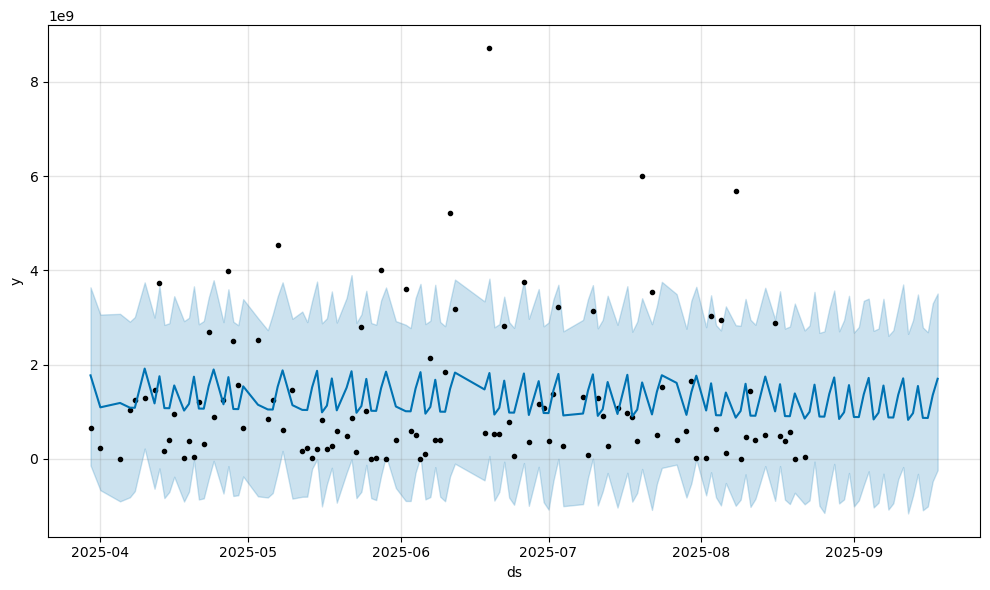

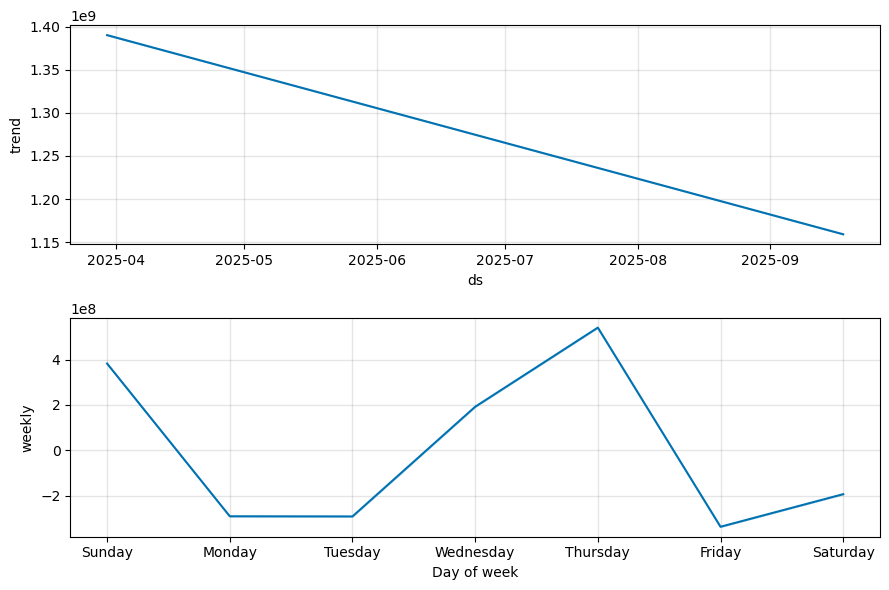

In [20]:
# ======================================
# Sales Forecasting with Prophet
# ======================================
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Prepare data (Prophet needs columns: ds, y)
prophet_df = df.groupby('date')['revenue'].sum().reset_index()
prophet_df.columns = ['ds', 'y']
prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])

# 2. Split data (80-20)
split_index = int(len(prophet_df) * 0.8)
train_df = prophet_df.iloc[:split_index]
test_df = prophet_df.iloc[split_index:]

# 3. Create and train Prophet model
model = Prophet(
    yearly_seasonality=False, 
    weekly_seasonality=True, 
    daily_seasonality=False, 
    changepoint_prior_scale=0.05 
)
model.fit(train_df)

# 4. Predict on test data
future = model.make_future_dataframe(periods=len(test_df))
forecast = model.predict(future)

# 5. Evaluate
y_pred = forecast['yhat'].iloc[-len(test_df):].values
y_test = test_df['y'].values

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Prophet Sales Forecast Model Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae:,.0f}")
print(f"Mean Squared Error (MSE): {mse:,.0f}")
print(f"Coefficient of Determination (R²): {r2:.3f}")

# 6. Plot results
fig1 = model.plot(forecast)
fig2 = model.plot_components(forecast)

# 7. Forecast next 7 days
future_7 = model.make_future_dataframe(periods=len(test_df) + 7)
forecast_7 = model.predict(future_7)
print("\n--- Sales Forecast Next 7 Days ---")
print(forecast_7[['ds', 'yhat']].tail(7))

In [10]:
# ======================================================
# 2. Customer churn prediction (classification)
# ======================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Create features for each customer for the churn model
# Define churn: a customer whose last purchase was more than 30 days ago
last_date = df['date'].max()
customer_features = df.groupby('customer_code').agg({
'revenue': ['sum', 'mean', 'count'],
'date': ['min', 'max']
}).reset_index()
customer_features.columns = ['customer_code', 'total_revenue', 'avg_revenue', 'purchase_count', 'first_date', 'last_date']
customer_features['days_since_last'] = (last_date - customer_features['last_date']).dt.days

# Define target (1 = churn, 0 = active)
customer_features['churn'] = (customer_features['days_since_last'] > 30).astype(int)

# 2. Features and Objective
X_churn = customer_features[['total_revenue', 'avg_revenue', 'purchase_count']]
y_churn = customer_features['churn']

# 3. Split the data
X_train_ch, X_test_ch, y_train_ch, y_test_ch = train_test_split(X_churn, y_churn, test_size=0.2, random_state=42)

# 4. Train the model
rf_churn = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_churn.fit(X_train_ch, y_train_ch)

# 5. Evaluation
y_pred_ch = rf_churn.predict(X_test_ch)
print("\n--- Evaluation of customer churn prediction model ---")
print(classification_report(y_test_ch, y_pred_ch))
print("Confusion matrix:\n", confusion_matrix(y_test_ch, y_pred_ch))



--- Evaluation of customer churn prediction model ---
              precision    recall  f1-score   support

           0       0.75      0.75      0.75        12
           1       0.75      0.75      0.75        12

    accuracy                           0.75        24
   macro avg       0.75      0.75      0.75        24
weighted avg       0.75      0.75      0.75        24

Confusion matrix:
 [[9 3]
 [3 9]]


Average distance between purchases: 1.5789340861421546
Customers with a purchase distance of less than 30 days: 106
Products purchased most times in a row: [(('855212402', '861641102'), 15), (('371016', '371020'), 12), (('813121020', '813121025'), 12), (('819141025', '819141020'), 11), (('1141', '1142'), 11), (('813121016', '813121020'), 11), (('855321301', '855321305'), 10), (('855321101', '855321501'), 10), (('855321305', '855321501'), 10), (('855321501', '855321301'), 10)]
Percentage of returning customers: 91.37931034482759
ouput successfully generated!


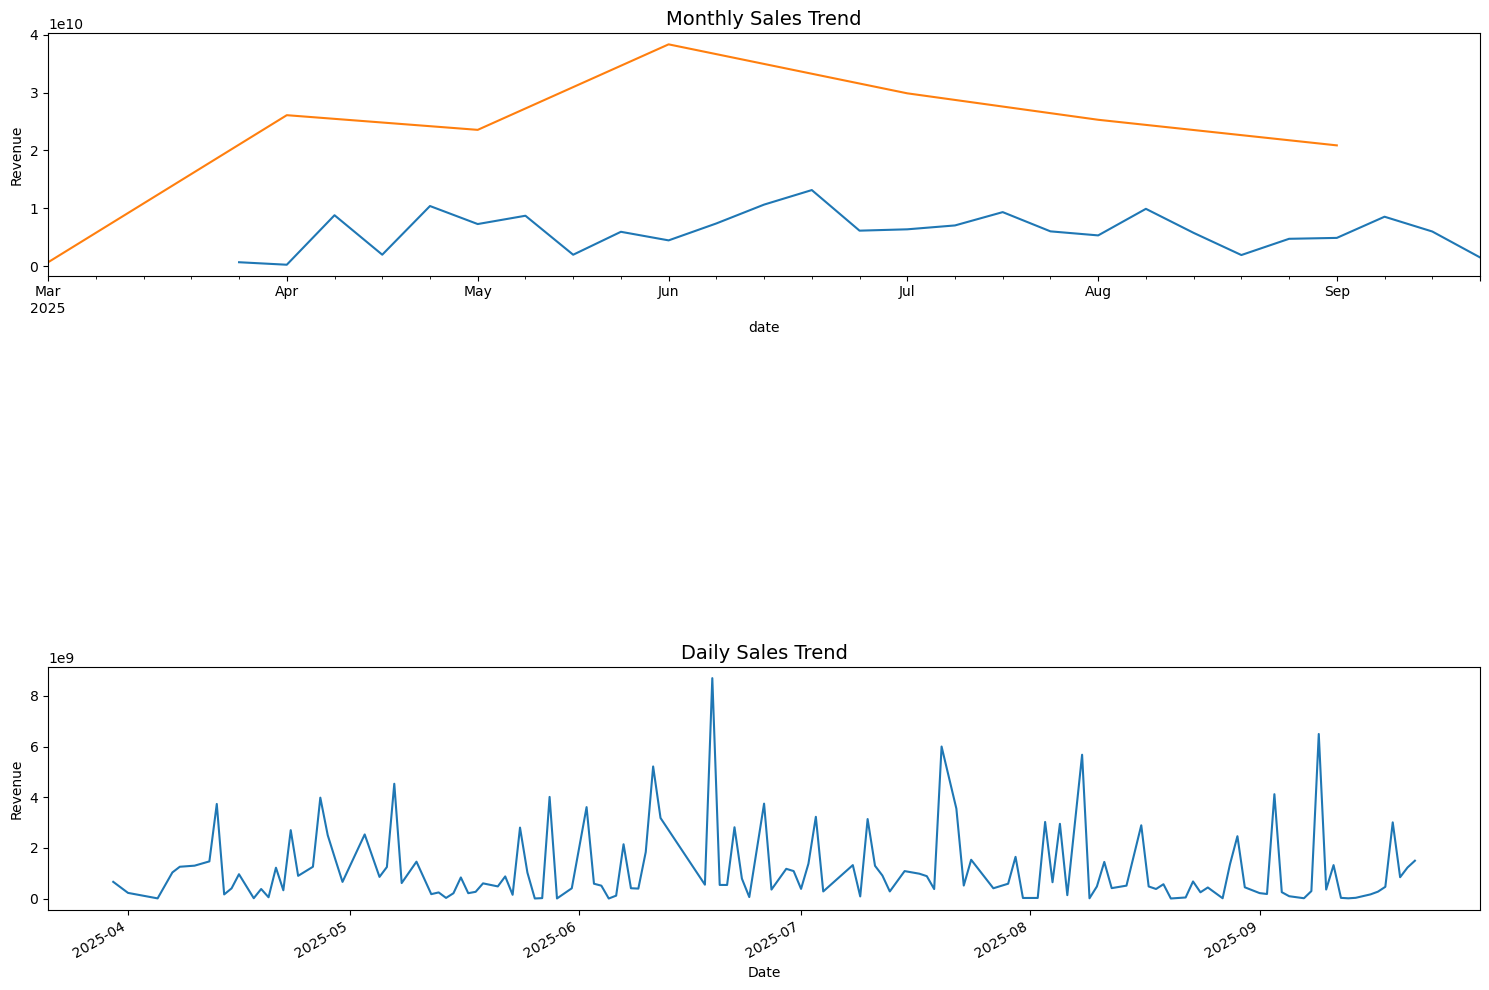

In [11]:
# ============================
# 3.Survival Analysis
# ==============================
# Calculate the distance between purchases for each customer
df_sorted = df.sort_values(['customer_code', 'date'])
df_sorted['prev_purchase_date'] = df_sorted.groupby('customer_code')['date'].shift(1)
df_sorted['days_between_purchases'] = (df_sorted['date'] - df_sorted['prev_purchase_date']).dt.days

# Average purchase distance for each customer
avg_days_between = df_sorted.groupby('customer_code')['days_between_purchases'].mean().dropna()
print("Average distance between purchases:", avg_days_between.mean())
print("Customers with a purchase distance of less than 30 days:", (avg_days_between < 30).sum())

# ===========================
# 5.Dynamic shopping cart analysis (order of purchases)
# ===========================
from collections import Counter

# Create a dictionary of each customer's purchases in chronological order
customer_purchases = {}
for _, row in df_sorted.iterrows():
    cust = row['customer_code']
    if cust not in customer_purchases:
        customer_purchases[cust] = []
    customer_purchases[cust].append(row['product_code'])

# Find products purchased after a specific product
follow_products = Counter()
for purchases in customer_purchases.values():
    for i in range(len(purchases)-1):
        follow_products[(purchases[i], purchases[i+1])] += 1

print("Products purchased most times in a row:", follow_products.most_common(10))

# ===========================
# 6.Return Rate Analysis
# ================================
# Identify new customers per month
df['year_month'] = df['date'].dt.to_period('M')
first_purchase = df.groupby('customer_code')['year_month'].min().reset_index()
first_purchase.columns = ['customer_code', 'first_month']

# Calculate return rate (minimum 2 purchases)
returning_customers = df.groupby('customer_code')['invoice_id'].count().reset_index()
returning_customers = returning_customers[returning_customers['invoice_id'] >= 2]
print("Percentage of returning customers:", (len(returning_customers) / df['customer_code'].nunique()) * 100)


# ============================
# 7.Seasonal analysis and sales trends
# ==============================
import matplotlib.pyplot as plt

# Daily, weekly and monthly sales analysis
daily_sales = df.groupby('date')['revenue'].sum()
weekly_sales = daily_sales.resample('W').sum()
monthly_sales = daily_sales.resample('ME').sum()

# Draw trend charts
plt.figure(figsize=(15, 10))
plt.subplot(3,1,1)
weekly_sales.plot()
plt.title('Weekly Sales Trend', fontsize=14)
plt.ylabel('Revenue')

plt.subplot(3,1,1)
monthly_sales.plot()
plt.title('Monthly Sales Trend', fontsize=14)
plt.ylabel('Revenue')

plt.subplot(3,1,3)
daily_sales.plot()
plt.title('Daily Sales Trend', fontsize=14)
plt.ylabel('Revenue')
plt.xlabel('Date')

plt.tight_layout()

plt.savefig('output/sales_trends.png', dpi=300, bbox_inches = 'tight')
print('ouput successfully generated!')

plt.show()

In [22]:
df['invoice_id'] = df['invoice_id'].astype(str)
df['customer_code'] = df['customer_code'].astype(str)
df['product_code'] = df['product_code'].astype(str)
df['revenue'] = df['revenue'].astype(float)
df['unit_price'] = df['unit_price'].astype(float)
df['row_id'] = df['row_id'].astype(str)

if 'invoice_date' in df.columns:
    df = df.drop(columns = ['invoice_date'])

print(df.dtypes)

df.to_csv('sales_data_cleaned.csv', index=False)

invoice_id               object
customer_code            object
product_code             object
quantity                float64
unit_price              float64
row_id                   object
revenue                 float64
date             datetime64[ns]
weekday                  object
weekday_num               int32
year_month            period[M]
dtype: object
